# CONUS404: Monthly Precipitation over the Contiguous US

```{image} ../../thumbnails/gdex_logo.png
:alt: GDEX Cookbook logo
:width: 200px
```

---

## Overview

CONUS404 is a 4-km, hourly, 43-year hydroclimate reanalysis of the contiguous
United States, produced by NCAR and the USGS by dynamically downscaling ERA5 with
the WRF model in a convection-permitting configuration
([Rasmussen et al., 2023](https://journals.ametsoc.org/view/journals/bams/104/8/BAMS-D-21-0326.1.xml)).
GDEX hosts it as dataset [`d559000`](https://gdex.ucar.edu/datasets/d559000/).

The native data is ~377,000 hourly NetCDF files; GDEX exposes them through a single
[kerchunk](https://fsspec.github.io/kerchunk/) reference, so we can slice the record
with one `xarray` call and stream only the bytes we need — here, over HTTPS.

We map total precipitation for a **single month** over CONUS — a scaled-down view
of the multi-year climatology in Rasmussen et al. (2023, Fig. 3), kept light enough
to run interactively.

1. Open CONUS404 2D output from a kerchunk reference over HTTPS
2. Select one month of hourly precipitation
3. Sum to a monthly total
4. Map it over CONUS on the model's Lambert Conformal grid

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [ERA5 Reanalysis Data Workflow](era5.ipynb) | Helpful | The kerchunk reference access pattern |
| [xarray](https://docs.xarray.dev) | Necessary | Labeled N-D arrays |
| [Dask](https://docs.dask.org) | Necessary | Parallel / out-of-core compute |
| [Cartopy](https://scitools.org.uk/cartopy) | Necessary | Mapping |

- **Time to learn**: 30 minutes

---

## Imports

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.distributed import LocalCluster

## Spin up a Dask cluster

Summing a month of hourly 4-km precipitation streams a few GB of chunks. A
`LocalCluster` reads them in parallel and keeps memory bounded.

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=2,
    memory_limit="4GiB",  # per worker
)
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44355,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34911,Total threads: 2
Dashboard: http://127.0.0.1:42295/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:41175,


## CONUS404 on GDEX

GDEX publishes a kerchunk reference for all **2D** CONUS404 variables (`wrf2d`) —
precipitation, 2-m temperature, surface fluxes, and more. We open it over HTTPS and
pull out hourly accumulated precipitation, `PREC_ACC_NC` (mm), along with the static
2D lat/lon needed for mapping.

In [3]:
%%time
kerchunk_url = "https://data.gdex.ucar.edu/d559000/kerchunk/wrf2d-remote-https.parq"

ds = xr.open_dataset(kerchunk_url, engine="kerchunk", \
                     storage_options={"remote_protocol": "https"})
pr = ds["PREC_ACC_NC"]
lat2d = ds["XLAT"].isel(Time=0)
lon2d = ds["XLONG"].isel(Time=0)
pr

CPU times: user 15.9 s, sys: 2.06 s, total: 18 s
Wall time: 1min 18s


<xarray.DataArray 'PREC_ACC_NC' (Time: 376944, south_north: 1015,
                                 west_east: 1367)> Size: 2TB
[523011684720 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 3MB 1979-10-01 ... 2022-09-30T23:00:00
    XTIME    (Time) datetime64[ns] 3MB ...
    XLAT     (Time, south_north, west_east) float32 2TB ...
    XLONG    (Time, south_north, west_east) float32 2TB ...
Dimensions without coordinates: south_north, west_east
Attributes:
    description:  ACCUMULATED GRID SCALE  PRECIPITATION OVER prec_acc_dt PERI...
    units:        mm
    stagger:       
    long_name:    Accumulated grid scale  precipitation , accumulated over pr...

In [4]:
%%time
month = "2017-02"
pr_month = pr.sel(Time=month).sum("Time").compute()

CPU times: user 12.6 s, sys: 1.4 s, total: 14 s
Wall time: 2min 41s


## Mapping the monthly total

CONUS404 sits on a Lambert Conformal grid. We coarsen 4× for plotting (to spare
Cartopy memory) and use the NCL `precip3_16lev` palette.

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


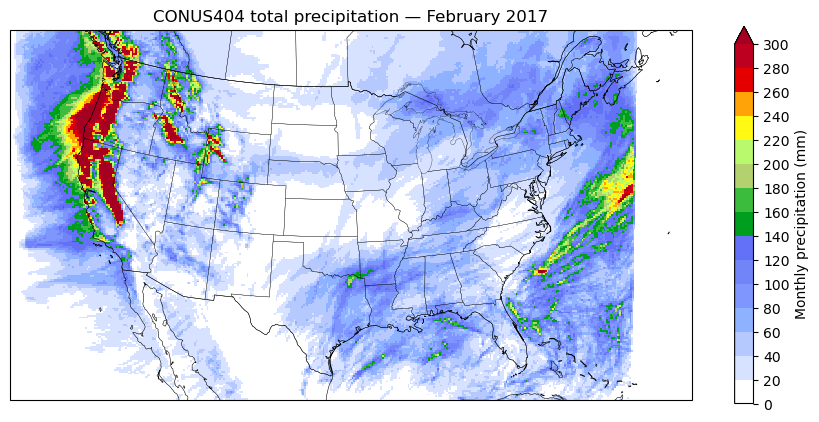

In [5]:
proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
trans = ccrs.PlateCarree()

_rgb255 = [
    (255, 255, 255), (214, 226, 255), (181, 201, 255), (142, 178, 255),
    (127, 150, 255), (114, 133, 248), (99, 112, 248), (0, 158, 30),
    (60, 188, 61), (179, 209, 110), (185, 249, 110), (255, 249, 19),
    (255, 163, 9), (229, 0, 0), (189, 0, 31), (165, 0, 33),
]
cmap_pr = ListedColormap(np.array(_rgb255) / 255, name="precip3_16lev")
levels = np.arange(0, 301, 20)
norm = BoundaryNorm(levels, ncolors=cmap_pr.N, extend="max")

kw = dict(south_north=4, west_east=4, boundary="trim")
pr_plot = pr_month.coarsen(**kw).mean()
lat_plot = lat2d.coarsen(**kw).mean()
lon_plot = lon2d.coarsen(**kw).mean()

fig, ax = plt.subplots(figsize=(11, 7), subplot_kw={"projection": proj})
im = ax.pcolormesh(
    lon_plot.values, lat_plot.values, pr_plot.values,
    transform=trans, cmap=cmap_pr, norm=norm, shading="auto",
)
ax.add_feature(cfeature.COASTLINE, lw=0.4)
ax.add_feature(cfeature.BORDERS, lw=0.4)
ax.add_feature(cfeature.STATES, lw=0.2)
ax.set_extent([-125, -66, 24, 50], crs=trans)

fig.colorbar(im, ax=ax, shrink=0.7, ticks=levels, extend="max",
             label="Monthly precipitation (mm)")
ax.set_title("CONUS404 total precipitation — February 2017")
plt.show()

In [6]:
client.close()
cluster.close()

---

## Summary

We opened CONUS404's 2D output from a single kerchunk reference over OSDF, summed
one month of hourly precipitation, and mapped the total across CONUS on the model's
native Lambert Conformal grid. Scoping to one month keeps the stream small — loop
the reduction over months or water years to rebuild the published multi-year
climatology.

## Resources and references

- [GDEX CONUS404 dataset (`d559000`)](https://gdex.ucar.edu/datasets/d559000/)
- [Rasmussen et al. (2023, BAMS)](https://journals.ametsoc.org/view/journals/bams/104/8/BAMS-D-21-0326.1.xml)
- [Original GDEX CONUS404 example](https://ncar.github.io/gdex-examples/conus404/)
- [xarray documentation](https://docs.xarray.dev)
- [kerchunk documentation](https://fsspec.github.io/kerchunk/)